In [7]:
#             import sys
# import tensorflow as tf
# import pandas as pd
# import sklearn
# import streamlit

# print("="*50)
# print("Python Executable :", sys.executable)
# print("TensorFlow        :", tf.__version__)
# print("Pandas            :", pd.__version__)
# print("Scikit-learn      :", sklearn.__version__)
# print("Streamlit         :", streamlit.__version__)
# print("="*50)

# Phase -1: Data Understanding

In [8]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv(r'/content/drive/MyDrive/Data Science /DL_Datasets/my_dataframe.csv')

## 1.Basic Information

In [11]:
df.shape

(47837, 3)

In [12]:
df.head(2)

,Document,Topic_group,priority
0,connection with icon icon dear please setup ic...,Hardware,High
1,work experience user work experience user hi w...,Access,Low


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
 2   priority     47837 non-null  object
dtypes: object(3)
memory usage: 1.1+ MB


## 2. Check Missing Values

In [18]:
df.isnull().sum()

,0
Document,0
Topic_group,0
priority,0


## 3. Check Duplicates

In [19]:
df.duplicated(subset=['Document']).sum()

np.int64(0)

## Ticket Type

In [20]:
df['Topic_group'].value_counts(normalize=True)

,proportion
Topic_group,
Hardware,0.284654
HR Support,0.228171
Access,0.148943
Miscellaneous,0.147585
Storage,0.058051
Purchase,0.051508
Internal Project,0.044296
Administrative rights,0.036792


## Ticket Priority

In [ ]:
df['Priority_Level'].value_counts(normalize=True)

# Phase-2: Exploratory Data Analysis

## Priority

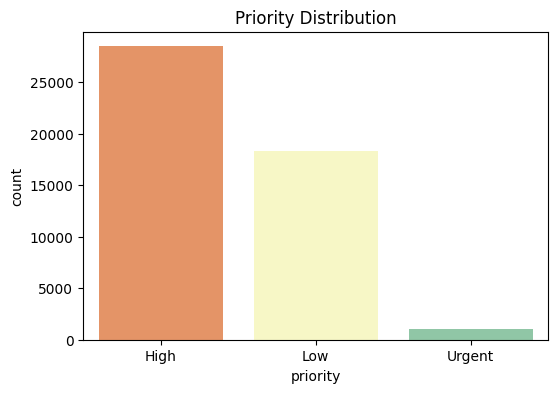

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df, x="priority", order=df["priority"].value_counts().index,palette="Spectral"
)

plt.title("Priority Distribution")

plt.show()

## Type

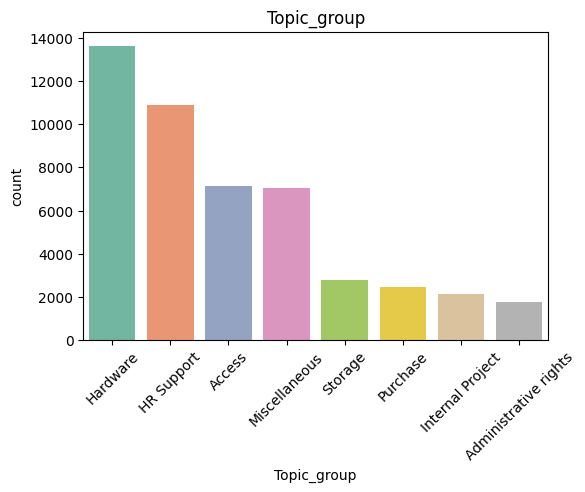

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Topic_group",
    order=df["Topic_group"].value_counts().index,
    palette='Set2'
)

plt.title('Topic_group')
plt.xticks(rotation =45)

plt.show()

## Priority

In [24]:
df['priority'].value_counts(normalize=True)

,proportion
priority,
High,0.595167
Low,0.382403
Urgent,0.022430


## Type

In [25]:
df['Topic_group'].value_counts(normalize=True)

,proportion
Topic_group,
Hardware,0.284654
HR Support,0.228171
Access,0.148943
Miscellaneous,0.147585
Storage,0.058051
Purchase,0.051508
Internal Project,0.044296
Administrative rights,0.036792


 # Phase-3: NLP preprocessing

In [26]:
import nltk

nltk.download('stopwords')
nltk.download('punct')
nltk.download('wordnet')
nltk.download('omw-1.4') # Open Multilingual WordNet (handles mice --> mouse, wolfves --> wolf)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Error loading punct: Package 'punct' not found in index
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [27]:
pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.1 MB/s eta 0:00:00


## Cleaning Text

In [28]:
import re
import nltk
import contractions
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

### Classical Clean Text

In [29]:
lemmatizer = WordNetLemmatizer()
STOP_WORDS = stopwords.words('english')
def classical_clean_text(text):
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = text.replace('\\n',' ')
    text = re.sub(r'[^a-zA-Z\s]','',text)
    text = re.sub(r"\s+", " ", text).strip()
    text = text.split()
    text = [lemmatizer.lemmatize(word) for word in text if word not in STOP_WORDS]

    return ' '.join(text)

### Deep Learning clean text

In [30]:
def dl_clean_text(text):


    text = text.lower()
    text = contractions.fix(text)
    text = text.replace('\\n',' ')
    text = re.sub(r'[^a-zA-Z\s]','',text)

    return text

# Phase-4: LSTM Model

In [49]:
df["text_dl"] = df['Document'].apply(dl_clean_text)

In [50]:
X = df['text_dl']
y = df['Topic_group']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)

### Label Encode the target

In [52]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

### Step-1: Tokenizer

In [53]:
from tensorflow.keras.preprocessing.text import Tokenizer

VOCAB_SIZE = 20000

tokenizer = Tokenizer(num_words=VOCAB_SIZE,oov_token="<OOV>")

tokenizer.fit_on_texts(X_train)

### Step-2: Sequence

In [54]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [55]:
print(X_train_seq[:2])

[[610, 239, 234, 7, 295, 711, 12, 20, 610, 234, 7, 711, 4, 67, 9, 2, 296, 485, 464, 610, 234, 7, 1448, 1077, 7, 81, 6, 9, 12, 20, 234, 7, 1448, 1244, 19, 2, 32, 361, 234, 7, 711, 245, 272, 3129, 596, 272, 2, 32, 6388, 150, 1218, 165, 9, 189, 32, 329, 398, 2061, 1537, 111, 2, 884, 370, 7705, 51, 401, 1559, 6, 9, 5], [79, 82, 7, 1057, 596, 168, 129, 31, 1296, 158, 20, 27, 3, 79, 596, 168, 129, 31, 158, 19, 2, 842, 799, 2, 34, 237, 687, 267, 271, 11, 79, 119, 98, 101, 529]]


In [56]:
df["word_count"] = df["text_dl"].str.split().str.len()

df["word_count"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]) # take 95% value 96 --> round value 100

,word_count
count,47837.000000
mean,43.652570
std,56.790948
min,2.000000
50%,27.000000
90%,91.000000
95%,137.000000
99%,284.640000
max,984.000000


### Step-3: Padding

In [57]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
MAX_LEN = 300

X_train_pad = pad_sequences(X_train_seq,maxlen=MAX_LEN,padding='post',truncating='post')

X_test_pad = pad_sequences(X_test_seq,maxlen=MAX_LEN,padding='post',truncating='post')

### Step-4: Build LSTM Model

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, LSTM, Dropout, GRU, Bidirectional

In [60]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

In [61]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import SpatialDropout1D

NUM_CLASSES = len(le.classes_)
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAX_LEN, mask_zero=True),
    SpatialDropout1D(0.3),
    LSTM(64, dropout=0.3, recurrent_dropout=0.3, kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation='softmax')
])
model.compile(metrics=['accuracy'], loss='sparse_categorical_crossentropy', optimizer='adam')

### Step-5: Train

In [62]:
history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    batch_size=128,
    epochs=5,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/5
240/240 ━━━━━━━━━━━━━━━━━━━━ 237s 964ms/step - accuracy: 0.4451 - loss: 1.5578 - val_accuracy: 0.7238 - val_loss: 0.9142 - learning_rate: 0.0010
Epoch 2/5
240/240 ━━━━━━━━━━━━━━━━━━━━ 267s 982ms/step - accuracy: 0.7144 - loss: 0.9613 - val_accuracy: 0.7711 - val_loss: 0.7194 - learning_rate: 0.0010
Epoch 3/5
240/240 ━━━━━━━━━━━━━━━━━━━━ 236s 985ms/step - accuracy: 0.7722 - loss: 0.7937 - val_accuracy: 0.8062 - val_loss: 0.6639 - learning_rate: 0.0010
Epoch 4/5
240/240 ━━━━━━━━━━━━━━━━━━━━ 225s 937ms/step - accuracy: 0.8003 - loss: 0.7220 - val_accuracy: 0.8287 - val_loss: 0.6086 - learning_rate: 0.0010
Epoch 5/5
240/240 ━━━━━━━━━━━━━━━━━━━━ 230s 961ms/step - accuracy: 0.8247 - loss: 0.6577 - val_accuracy: 0.8316 - val_loss: 0.6029 - learning_rate: 0.0010


### Step-6: Evaluation

In [64]:
train_loss, train_accuracy = model.evaluate(X_train_pad, y_train)
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Train - Test Gap:", round(train_accuracy - test_accuracy, 4))

1196/1196 ━━━━━━━━━━━━━━━━━━━━ 115s 96ms/step - accuracy: 0.8783 - loss: 0.4487
299/299 ━━━━━━━━━━━━━━━━━━━━ 26s 87ms/step - accuracy: 0.8270 - loss: 0.5994
Train Accuracy: 0.8783349394798279
Test Accuracy: 0.8270276188850403
Train - Test Gap: 0.0513


# GRU

In [71]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

In [72]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import SpatialDropout1D

NUM_CLASSES = len(le.classes_)
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAX_LEN, mask_zero=True),
    SpatialDropout1D(0.3),
    GRU(64, dropout=0.3, recurrent_dropout=0.3, kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation='softmax')
])
model.compile(metrics=['accuracy'], loss='sparse_categorical_crossentropy', optimizer='adam')

In [73]:
history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    batch_size=128,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 219s 864ms/step - accuracy: 0.4030 - loss: 1.6071 - val_accuracy: 0.6466 - val_loss: 1.0635 - learning_rate: 0.0010
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 268s 891ms/step - accuracy: 0.6497 - loss: 1.0580 - val_accuracy: 0.7403 - val_loss: 0.7878 - learning_rate: 0.0010
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 255s 863ms/step - accuracy: 0.7443 - loss: 0.8171 - val_accuracy: 0.8143 - val_loss: 0.6142 - learning_rate: 0.0010
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 209s 873ms/step - accuracy: 0.7960 - loss: 0.6780 - val_accuracy: 0.8290 - val_loss: 0.5532 - learning_rate: 0.0010
Epoch 5/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 255s 846ms/step - accuracy: 0.8203 - loss: 0.6116 - val_accuracy: 0.8372 - val_loss: 0.5211 - learning_rate: 0.0010
Epoch 6/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 208s 867ms/step - accuracy: 0.8386 - loss: 0.5574 - val_accuracy: 0.8431 - val_loss: 0.5156 - learning_rate: 0.0010
Epoch 7/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 263s 871ms/step - accura

In [74]:
train_loss, train_accuracy = model.evaluate(X_train_pad, y_train)
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Train - Test Gap:", round(train_accuracy - test_accuracy, 4))

1196/1196 ━━━━━━━━━━━━━━━━━━━━ 94s 79ms/step - accuracy: 0.9068 - loss: 0.3324
299/299 ━━━━━━━━━━━━━━━━━━━━ 23s 78ms/step - accuracy: 0.8498 - loss: 0.4972
Train Accuracy: 0.9068175554275513
Test Accuracy: 0.849811851978302
Train - Test Gap: 0.057


# BiDirectional LSTM

In [75]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

In [77]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import SpatialDropout1D

NUM_CLASSES = len(le.classes_)
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAX_LEN, mask_zero=True),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3, kernel_regularizer=l2(1e-4))),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation='softmax')
])
model.compile(metrics=['accuracy'], loss='sparse_categorical_crossentropy', optimizer='adam')

In [79]:
history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    batch_size=128,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 487s 2s/step - accuracy: 0.5763 - loss: 1.2586 - val_accuracy: 0.8082 - val_loss: 0.6336 - learning_rate: 0.0010
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 457s 2s/step - accuracy: 0.8010 - loss: 0.6829 - val_accuracy: 0.8358 - val_loss: 0.5404 - learning_rate: 0.0010
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 455s 2s/step - accuracy: 0.8399 - loss: 0.5696 - val_accuracy: 0.8410 - val_loss: 0.5311 - learning_rate: 0.0010
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 449s 2s/step - accuracy: 0.8541 - loss: 0.5214 - val_accuracy: 0.8444 - val_loss: 0.5102 - learning_rate: 0.0010
Epoch 5/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 453s 2s/step - accuracy: 0.8698 - loss: 0.4688 - val_accuracy: 0.8445 - val_loss: 0.5175 - learning_rate: 0.0010
Epoch 6/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 453s 2s/step - accuracy: 0.8754 - loss: 0.4508 - val_accuracy: 0.8436 - val_loss: 0.5218 - learning_rate: 0.0010
Epoch 7/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 498s 2s/step - accuracy: 0.8852 - loss: 0.

In [80]:
train_loss, train_accuracy = model.evaluate(X_train_pad, y_train)
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Train - Test Gap:", round(train_accuracy - test_accuracy, 4))

1196/1196 ━━━━━━━━━━━━━━━━━━━━ 201s 168ms/step - accuracy: 0.8990 - loss: 0.3546
299/299 ━━━━━━━━━━━━━━━━━━━━ 47s 158ms/step - accuracy: 0.8448 - loss: 0.5007
Train Accuracy: 0.8990305662155151
Test Accuracy: 0.8447951674461365
Train - Test Gap: 0.0542


## Export GRU model

In [ ]:
import pickle

# Save the GRU model (best of the three — 0.850 test accuracy)
model.save('gru_model.keras')

# tokenizer and label encoder are shared across LSTM/GRU/BiLSTM,
# so saving them here is safe regardless of run order
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('Saved: gru_model.keras, tokenizer.pkl, label_encoder.pkl')